# NB08 — Timeline Scoring Expansion (CDTS Component d, prep)

**Goal:** score DF40 generators spanning the 2016->2024 release timeline, so component (d)
Calibration-Drift Early Warning has a real timeline to detect drift across.

**14 new generators** (combined with 8 already scored = 22 spanning all eras):
- 2016: faceswap (FS)
- 2019: fsgan (FS), wav2lip (FR)
- 2021: StyleGAN3 (EFS), pirender (FR), e4e (FE)
- 2022: StyleGANXL (EFS), DiT (EFS), lia (FR)
- 2023: facedancer (FS), sadtalker (FR), pixart (EFS, 19.5GB - slow)
- 2024: rddm (EFS), SiT (EFS)

**Same proven flow** (NB03/NB06): FS Xception, cdf JSONs, Celeb-DF reals, unzip->manifest->
remap->score. **Per-method checkpointing:** each method's scores save to Drive immediately;
the loop SKIPS already-scored methods, so a runtime drop loses nothing -- just re-run.

Scores from the SHORTCUT (not the local core copy) since these aren't in df40_core.


## Cell 1 — Setup + load FS Xception

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import os, sys, glob, subprocess
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
PARENT = "/content/drive/MyDrive/CDTS_Research"
DFB = f"{REPO}/external/DeepfakeBench"
for f in [".gitconfig",".git-credentials"]:
    if os.path.exists(f"{PARENT}/{f}"): subprocess.run(f'cp "{PARENT}/{f}" /root/{f}', shell=True)
subprocess.run("git config --global credential.helper store", shell=True)
print("installing deps..."); subprocess.run("pip -q install efficientnet_pytorch timm einops kornia simplejson", shell=True)

import importlib.util
for k in list(sys.modules.keys()):
    if k.startswith("detectors") or k.startswith("networks") or k=="metrics" or k.startswith("metrics.") or k=="inference":
        del sys.modules[k]
sys.path = [p for p in sys.path if p not in (f"{DFB}/training", f"{REPO}/src", DFB)]
sys.path.insert(0, DFB); sys.path.insert(0, f"{DFB}/training"); sys.path.append(f"{REPO}/src")
spec = importlib.util.spec_from_file_location("inference", f"{REPO}/src/inference.py")
inference = importlib.util.module_from_spec(spec); sys.modules["inference"]=inference
spec.loader.exec_module(inference)
model, device, info = inference.load_detector(dfb_root=DFB, backbone_name="xception",
    ckpt_path=f"{REPO}/weights/train_on_fs/xception.pth")
print("FS Xception load:", info, "device:", device)

Mounted at /content/drive
installing deps...
FS Xception load: {'missing': 0, 'unexpected': 0} device: cuda


## Cell 2 — Score the 14 new generators (checkpointed, skips done)

Scores from the DF40 SHORTCUT. Each method: unzip to local -> manifest (cdf JSON) ->
remap fakes to local + reals to Celeb-DF -> score -> save to Drive -> delete local frames.
SKIPS any method whose score parquet already exists (so re-run after a drop is safe).


In [2]:
import os, glob, zipfile, shutil
import pandas as pd, importlib.util, sys
from sklearn.metrics import roc_auc_score
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
SHORTCUT = "/content/drive/MyDrive/CDTS_Research/DF40"

spec = importlib.util.spec_from_file_location("data_prep", f"{REPO}/src/data_prep.py")
data_prep = importlib.util.module_from_spec(spec); sys.modules["data_prep"]=data_prep
spec.loader.exec_module(data_prep)

CDF_REAL = f"{REPO}/data/frames/Celeb-DF-v2"
real_index = {"/".join(fp.split("/")[-2:]): fp for fp in glob.glob(f"{CDF_REAL}/**/frames/**/*.png", recursive=True)}
print(f"real index: {len(real_index)}\n")

# era-ordered new methods (zip name in shortcut -> cdf JSON stem must match)
# note: some zip names differ slightly from JSON stems; map carefully
NEW = [
    ("faceswap","faceswap","2016","FS"),
    ("fsgan","fsgan","2019","FS"),
    ("wav2lip","wav2lip","2019","FR"),
    ("StyleGAN3","StyleGAN3","2021","EFS"),
    ("pirender","pirender","2021","FR"),
    ("e4e","e4e","2021","FE"),
    ("StyleGANXL","StyleGANXL","2022","EFS"),
    ("DiT","DiT","2022","EFS"),
    ("lia","lia","2022","FR"),
    ("facedancer","facedancer","2023","FS"),
    ("sadtalker","sadtalker","2023","FR"),
    ("rddm","rddm","2024","EFS"),
    ("SiT","SiT","2024","EFS"),
    ("pixart","pixart","2023","EFS"),   # 19.5GB - LAST so the 13 fast methods bank first
]

for zipname, jstem, era, fam in NEW:
    out = f"{REPO}/reports/scores/xceptionFS_df40_{zipname}.parquet"
    if os.path.exists(out):
        print(f"=== {zipname} [{era}/{fam}] -- already scored, SKIP ==="); continue
    print(f"=== {zipname} [{era}/{fam}] ===")
    zp = f"{SHORTCUT}/{zipname}.zip"
    jpath = f"{REPO}/data/df40/dataset_json/{jstem}_cdf.json"
    if not os.path.exists(zp):
        print(f"  zip not in shortcut, SKIP"); continue
    if not os.path.exists(jpath):
        print(f"  {jstem}_cdf.json missing, SKIP"); continue
    if os.path.getsize(zp) < 1e6:
        print(f"  zip is empty/corrupt ({os.path.getsize(zp)} bytes), SKIP"); continue

    fdir = f"/content/df40tl_{zipname}"
    try:
        if not os.path.isdir(fdir):
            os.makedirs(fdir, exist_ok=True)
            with zipfile.ZipFile(zp) as z: z.extractall(fdir)
        fake_index = {"/".join(fp.split("/")[-2:]): fp for fp in glob.glob(f"{fdir}/**/*.png", recursive=True)}
        df = data_prep.build_manifest_from_json(f"{jstem}_cdf", jpath, frames_root=None)
        def remap(row):
            key = "/".join(row["frame_path"].split("/")[-2:])
            return fake_index.get(key) if row["label"]==1 else real_index.get(key)
        df["frame_path"] = df.apply(remap, axis=1)
        df = df[df["frame_path"].notna()].reset_index(drop=True)
        if df['label'].nunique() < 2:
            print(f"  one label only ({df['label'].value_counts().to_dict()}), SKIP"); shutil.rmtree(fdir, ignore_errors=True); continue
        scores = inference.score_manifest(model, device, df, batch_size=64, verbose=False)
        scores.to_parquet(out, index=False)
        auc = roc_auc_score(scores.label, scores.prob_fake)
        print(f"  AUC = {auc:.4f}  (n={len(scores)})  -> saved")
    except Exception as e:
        print(f"  ERROR: {str(e)[:150]}")
    finally:
        shutil.rmtree(fdir, ignore_errors=True)

print("\n=== scoring pass done ===")
done = sorted(glob.glob(f"{REPO}/reports/scores/xceptionFS_df40_*.parquet"))
print(f"total DF40 FS scores now: {len(done)}")
for d in done: print("  ", os.path.basename(d).replace("xceptionFS_df40_","").replace(".parquet",""))

real index: 16420

=== faceswap [2016/FS] ===
  AUC = 0.8921  (n=25793)  -> saved
=== fsgan [2019/FS] ===
  AUC = 0.9046  (n=25221)  -> saved
=== wav2lip [2019/FR] ===
  AUC = 0.4833  (n=26434)  -> saved
=== StyleGAN3 [2021/EFS] ===
  AUC = 0.6855  (n=33794)  -> saved
=== pirender [2021/FR] ===
  AUC = 0.6969  (n=25805)  -> saved
=== e4e [2021/FE] ===
  ERROR: That compression method is not supported
=== StyleGANXL [2022/EFS] ===
  AUC = 0.6489  (n=33794)  -> saved
=== DiT [2022/EFS] ===
  AUC = 0.5300  (n=33794)  -> saved
=== lia [2022/FR] ===
  AUC = 0.6121  (n=25426)  -> saved
=== facedancer [2023/FS] ===
  AUC = 0.9281  (n=25872)  -> saved
=== sadtalker [2023/FR] ===
  AUC = 0.4657  (n=26606)  -> saved
=== rddm [2024/EFS] ===
  zip not in shortcut, SKIP
=== SiT [2024/EFS] ===
  AUC = 0.5605  (n=33794)  -> saved
=== pixart [2023/EFS] ===
  AUC = 0.4391  (n=33794)  -> saved

=== scoring pass done ===
total DF40 FS scores now: 20
   DiT
   SiT
   StyleGAN2
   StyleGAN3
   StyleGANXL
 

In [3]:
import os, glob, zipfile, shutil, subprocess
import pandas as pd, importlib.util, sys
from sklearn.metrics import roc_auc_score
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
SHORTCUT = "/content/drive/MyDrive/CDTS_Research/DF40"

spec = importlib.util.spec_from_file_location("data_prep", f"{REPO}/src/data_prep.py")
data_prep = importlib.util.module_from_spec(spec); sys.modules["data_prep"]=data_prep
spec.loader.exec_module(data_prep)
CDF_REAL = f"{REPO}/data/frames/Celeb-DF-v2"
real_index = {"/".join(fp.split("/")[-2:]): fp for fp in glob.glob(f"{CDF_REAL}/**/frames/**/*.png", recursive=True)}

# (zipfile_in_shortcut, json_stem, score_name)  -- handle case mismatch + compression
RECOVER = [
    ("RDDM", "rddm", "rddm"),    # zip is uppercase RDDM.zip, json is rddm_cdf
    ("e4e", "e4e", "e4e"),        # needs alternative unzip (compression)
]

for zipname, jstem, scorename in RECOVER:
    out = f"{REPO}/reports/scores/xceptionFS_df40_{scorename}.parquet"
    if os.path.exists(out):
        print(f"{scorename}: already scored, skip"); continue
    print(f"=== recovering {scorename} (zip={zipname}.zip) ===")
    zp = f"{SHORTCUT}/{zipname}.zip"
    jpath = f"{REPO}/data/df40/dataset_json/{jstem}_cdf.json"
    if not os.path.exists(zp):
        print(f"  {zipname}.zip not found"); continue
    if not os.path.exists(jpath):
        print(f"  {jstem}_cdf.json not found"); continue

    fdir = f"/content/df40rec_{scorename}"
    os.makedirs(fdir, exist_ok=True)
    # try python zipfile first, fall back to system unzip (handles more compression)
    try:
        with zipfile.ZipFile(zp) as z: z.extractall(fdir)
        print("  unzipped (python zipfile)")
    except Exception as e:
        print(f"  zipfile failed ({str(e)[:50]}), trying system unzip...")
        # install 7z if needed, use it for exotic compression
        r = subprocess.run(f'unzip -q -o "{zp}" -d "{fdir}"', shell=True, capture_output=True, text=True)
        if r.returncode != 0:
            print("  unzip failed too, trying 7z...")
            subprocess.run("apt-get -qq install p7zip-full 2>/dev/null", shell=True)
            r2 = subprocess.run(f'7z x -y "{zp}" -o"{fdir}" 2>&1 | tail -2', shell=True, capture_output=True, text=True)
            print("  7z:", r2.stdout[-100:])

    pngs = glob.glob(f"{fdir}/**/*.png", recursive=True)
    print(f"  extracted {len(pngs)} pngs")
    if not pngs:
        print("  no frames extracted, skip"); shutil.rmtree(fdir, ignore_errors=True); continue

    fake_index = {"/".join(fp.split("/")[-2:]): fp for fp in pngs}
    df = data_prep.build_manifest_from_json(f"{jstem}_cdf", jpath, frames_root=None)
    def remap(row):
        key = "/".join(row["frame_path"].split("/")[-2:])
        return fake_index.get(key) if row["label"]==1 else real_index.get(key)
    df["frame_path"] = df.apply(remap, axis=1)
    df = df[df["frame_path"].notna()].reset_index(drop=True)
    if df['label'].nunique() < 2:
        print(f"  one label only, skip"); shutil.rmtree(fdir, ignore_errors=True); continue
    scores = inference.score_manifest(model, device, df, batch_size=64, verbose=False)
    scores.to_parquet(out, index=False)
    auc = roc_auc_score(scores.label, scores.prob_fake)
    print(f"  AUC = {auc:.4f}  (n={len(scores)})  -> saved")
    shutil.rmtree(fdir, ignore_errors=True)

print("\ndone. total DF40 FS scores now:", len(glob.glob(f"{REPO}/reports/scores/xceptionFS_df40_*.parquet")))

=== recovering rddm (zip=RDDM.zip) ===
  unzipped (python zipfile)
  extracted 17738 pngs
  AUC = 0.7294  (n=19647)  -> saved
=== recovering e4e (zip=e4e.zip) ===
  zipfile failed (That compression method is not supported), trying system unzip...
  extracted 0 pngs
  no frames extracted, skip

done. total DF40 FS scores now: 21


## Cell 3 — Calibrate ALL DF40 generators + assemble the era timeline

In [4]:
import sys, importlib.util, os, glob
import pandas as pd, numpy as np
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
for k in list(sys.modules.keys()):
    if k=="metrics" or k.startswith("metrics.") or k=="calibration": del sys.modules[k]
sys.path = [p for p in sys.path if "DeepfakeBench" not in p]
if f"{REPO}/src" in sys.path: sys.path.remove(f"{REPO}/src")
sys.path.insert(0, f"{REPO}/src")
import calibration as cal, metrics as met

# era + family map for ALL scored DF40 methods (for the timeline)
ERA = {"faceswap":("2016","FS"),"fsgan":("2019","FS"),"fomm":("2019","FR"),"wav2lip":("2019","FR"),
       "simswap":("2020","FS"),"StyleGAN2":("2020","EFS"),"ddim":("2020","EFS"),
       "StyleGAN3":("2021","EFS"),"pirender":("2021","FR"),"e4e":("2021","FE"),"facevid2vid":("2021","FR"),
       "StyleGANXL":("2022","EFS"),"DiT":("2022","EFS"),"lia":("2022","FR"),"sd2.1":("2022","EFS"),
       "blendface":("2023","FS"),"inswap":("2023","FS"),"facedancer":("2023","FS"),
       "sadtalker":("2023","FR"),"pixart":("2023","EFS"),
       "rddm":("2024","EFS"),"SiT":("2024","EFS")}

rows = []
for f in sorted(glob.glob(f"{REPO}/reports/scores/xceptionFS_df40_*.parquet")):
    method = os.path.basename(f).replace("xceptionFS_df40_","").replace(".parquet","")
    if method not in ERA: continue
    era, fam = ERA[method]
    s = pd.read_parquet(f)
    p = s.prob_fake.values.astype(float); y = s.label.values.astype(int)
    g = s.identity_id.values if "identity_id" in s.columns else None
    ci, ti, _ = cal.leakage_safe_split(y, groups=g, calib_frac=0.5, seed=42)
    p_cal, _ = cal.fit_predict("hybrid", p[ci], y[ci], p[ti], switch_threshold_n=1000)
    auc = met.roc_auc(p[ti], y[ti]) if hasattr(met,"roc_auc") else float("nan")
    ece_cal = met.ece(p_cal, y[ti], 15, "equal_mass")
    ece_raw = met.ece(p[ti], y[ti], 15, "equal_mass")
    rows.append({"method":method,"era":int(era),"family":fam,"n":int(len(ti)),
                 "AUC":round(auc,4),"ECE_raw":round(ece_raw,4),"ECE_cal":round(ece_cal,4)})

tl = pd.DataFrame(rows).sort_values(["era","method"]).reset_index(drop=True)
tl.to_csv(f"{REPO}/reports/calibration/timeline_df40_xceptionFS.csv", index=False)
print(f"=== DF40 era timeline ({len(tl)} generators) ===")
print(tl.to_string(index=False))
print(f"\neras covered: {sorted(tl.era.unique())}")
print(f"generators per era: {tl.era.value_counts().sort_index().to_dict()}")

=== DF40 era timeline (21 generators) ===
     method  era family     n    AUC  ECE_raw  ECE_cal
   faceswap 2016     FS 12892 0.8919   0.0688   0.0455
       fomm 2019     FR 12947 0.8008   0.1562   0.0544
      fsgan 2019     FS 12608 0.9004   0.1069   0.0364
    wav2lip 2019     FR 13196 0.4701   0.5110   0.2238
  StyleGAN2 2020    EFS 16967 0.6491   0.3257   0.0629
       ddim 2020    EFS 16967 0.7661   0.1973   0.0411
    simswap 2020     FS 12966 0.9478   0.0828   0.0238
  StyleGAN3 2021    EFS 16967 0.6792   0.2894   0.0596
facevid2vid 2021     FR 12805 0.8216   0.1343   0.0637
   pirender 2021     FR 12911 0.6880   0.2652   0.0894
        DiT 2022    EFS 16967 0.5214   0.4752   0.1608
 StyleGANXL 2022    EFS 16967 0.6374   0.3414   0.0932
        lia 2022     FR 12742 0.6068   0.3596   0.1462
      sd2.1 2022    EFS 16967 0.6879   0.2716   0.0442
  blendface 2023     FS 12930 0.9429   0.0807   0.0225
 facedancer 2023     FS 12962 0.9327   0.0704   0.0254
     inswap 2023     FS

## Cell 4 — Quick timeline visual (AUC + ECE_cal across eras) + commit

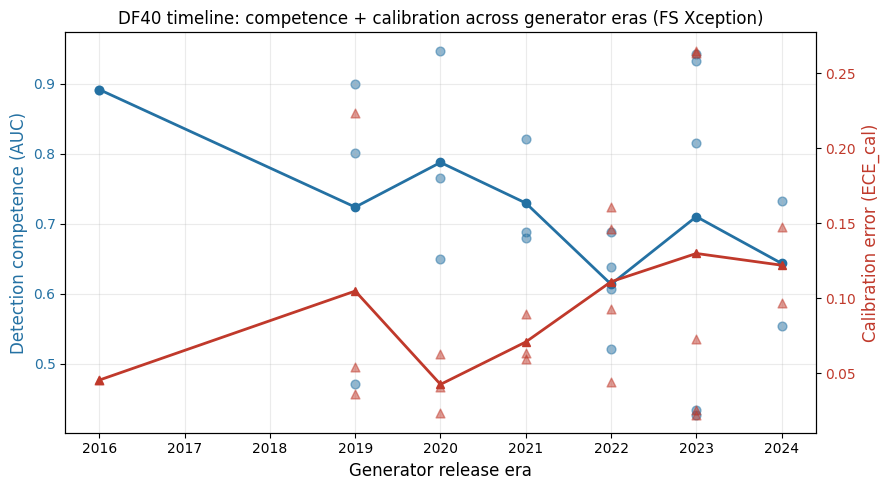

saved: /content/drive/MyDrive/CDTS_Research/deepfake-trust-research/figures/timeline_df40_competence_calibration.png

era means (the drift series for component d):
 era      AUC  ECE_cal  n
2016 0.891900 0.045500  1
2019 0.723767 0.104867  3
2020 0.787667 0.042600  3
2021 0.729600 0.070900  3
2022 0.613375 0.111100  4
2023 0.710140 0.129940  5
2024 0.643250 0.122100  2

staged:
  m external/DeepfakeBench
A  figures/timeline_df40_competence_calibration.png
 M notebooks/NB06_effnet_df40.ipynb
AM notebooks/NB08_timeline_scoring.ipynb
A  reports/calibration/timeline_df40_xceptionFS.csv
A  reports/scores/xceptionFS_df40_DiT.parquet
A  reports/scores/xceptionFS_df40_SiT.parquet
A  reports/scores/xceptionFS_df40_StyleGAN3.parquet
A  reports/scores/xceptionFS_df40_StyleGANXL.parquet
A  reports/scores/xceptionFS_df40_facedancer.parquet
A  reports/scores/xceptionFS_df40_faceswap.parquet
A  reports/scores/xceptionFS_df40_fsgan.parquet
A  reports/scores/xceptionFS_df40_lia.parquet
A  reports/score

In [5]:
import pandas as pd, numpy as np, os, glob
import matplotlib.pyplot as plt
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
tl = pd.read_csv(f"{REPO}/reports/calibration/timeline_df40_xceptionFS.csv")

# per-era mean (the drift series)
era_mean = tl.groupby("era").agg(AUC=("AUC","mean"), ECE_cal=("ECE_cal","mean"), n=("method","count")).reset_index()

fig, ax1 = plt.subplots(figsize=(9,5))
ax2 = ax1.twinx()
# scatter all generators
ax1.scatter(tl.era, tl.AUC, c="#2471A3", alpha=0.5, s=40, label="AUC (per generator)")
ax2.scatter(tl.era, tl.ECE_cal, c="#C0392B", alpha=0.5, s=40, marker="^", label="ECE_cal (per generator)")
# era-mean trend lines
ax1.plot(era_mean.era, era_mean.AUC, "o-", c="#2471A3", lw=2, label="AUC (era mean)")
ax2.plot(era_mean.era, era_mean.ECE_cal, "^-", c="#C0392B", lw=2, label="ECE_cal (era mean)")
ax1.set_xlabel("Generator release era", fontsize=12)
ax1.set_ylabel("Detection competence (AUC)", color="#2471A3", fontsize=12)
ax2.set_ylabel("Calibration error (ECE_cal)", color="#C0392B", fontsize=12)
ax1.set_title("DF40 timeline: competence + calibration across generator eras (FS Xception)", fontsize=12)
ax1.tick_params(axis='y', labelcolor="#2471A3"); ax2.tick_params(axis='y', labelcolor="#C0392B")
ax1.grid(True, alpha=0.25); fig.tight_layout()
out = f"{REPO}/figures/timeline_df40_competence_calibration.png"
plt.savefig(out, dpi=300, bbox_inches="tight"); plt.show()
print("saved:", out)
print("\nera means (the drift series for component d):")
print(era_mean.to_string(index=False))

# commit
import subprocess
os.chdir(REPO)
for f in [".gitconfig",".git-credentials"]:
    if os.path.exists(f"/content/drive/MyDrive/CDTS_Research/{f}"):
        subprocess.run(f'cp "/content/drive/MyDrive/CDTS_Research/{f}" /root/{f}', shell=True)
subprocess.run("git add reports/scores/xceptionFS_df40_*.parquet reports/calibration/timeline_df40_xceptionFS.csv figures/timeline_df40_competence_calibration.png notebooks/NB08_timeline_scoring.ipynb", shell=True)
r = subprocess.run("git status --short", shell=True, capture_output=True, text=True)
print("\nstaged:\n", r.stdout)
print(">>> review, then commit")

In [6]:
import pandas as pd, numpy as np
from scipy.stats import pearsonr, spearmanr
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
tl = pd.read_csv(f"{REPO}/reports/calibration/timeline_df40_xceptionFS.csv")

# 1) competence-coupling within the timeline
r, p = pearsonr(tl.AUC, tl.ECE_cal); rs, ps = spearmanr(tl.AUC, tl.ECE_cal)
print(f"1) Competence-coupling across 21 timeline generators:")
print(f"   AUC vs ECE_cal: Pearson r={r:.3f} (p={p:.2e}), Spearman={rs:.3f}")

# 2) naive temporal drift
r2, p2 = pearsonr(tl.era, tl.ECE_cal)
print(f"\n2) Naive temporal drift: era vs ECE_cal: r={r2:.3f} (p={p2:.3f})")

# 3) drift WITHIN FS family (the confound-controlled test)
fs = tl[tl.family=="FS"].sort_values("era")
if len(fs) >= 4:
    r3, p3 = pearsonr(fs.era, fs.ECE_cal)
    print(f"\n3) Drift WITHIN FS family ({len(fs)} gens, detector competent): era vs ECE_cal: r={r3:.3f} (p={p3:.3f})")
    print(f"   FS by era: {list(zip(fs.era, fs.AUC.round(3), fs.ECE_cal.round(3)))}")
    print(f"   => if NOT significant, the temporal 'drift' is a family-composition artifact, not true drift")

# 4) drift WITHIN EFS family (diffusion/synthesis - where competence is low)
efs = tl[tl.family=="EFS"].sort_values("era")
if len(efs) >= 4:
    r4, p4 = pearsonr(efs.era, efs.ECE_cal)
    print(f"\n4) Drift WITHIN EFS family ({len(efs)} gens): era vs ECE_cal: r={r4:.3f} (p={p4:.3f})")
    print(f"   EFS by era: {list(zip(efs.era, efs.AUC.round(3), efs.ECE_cal.round(3)))}")

# 5) family composition by era (the confound, explicit)
print(f"\n5) family composition by era:")
print(pd.crosstab(tl.era, tl.family).to_string())

# 6) is era predictive of ECE_cal AFTER controlling for AUC? (partial correlation)
from scipy.stats import pearsonr as pr
# residualize ECE_cal and era on AUC, correlate residuals
import numpy as np
def residuals(yvar, xvar):
    b = np.polyfit(xvar, yvar, 1); return yvar - (b[0]*xvar + b[1])
ece_resid = residuals(tl.ECE_cal.values, tl.AUC.values)
era_resid = residuals(tl.era.values.astype(float), tl.AUC.values)
rp_partial, pp_partial = pr(era_resid, ece_resid)
print(f"\n6) Partial corr: era vs ECE_cal CONTROLLING for AUC: r={rp_partial:.3f} (p={pp_partial:.3f})")
print(f"   => if ~0, era adds NOTHING beyond competence; the coupling (component a) explains the timeline.")
print(f"   => if still negative/significant, there's genuine temporal drift beyond competence.")

1) Competence-coupling across 21 timeline generators:
   AUC vs ECE_cal: Pearson r=-0.864 (p=4.44e-07), Spearman=-0.870

2) Naive temporal drift: era vs ECE_cal: r=0.298 (p=0.189)

3) Drift WITHIN FS family (6 gens, detector competent): era vs ECE_cal: r=-0.028 (p=0.958)
   FS by era: [(2016, 0.892, 0.046), (2019, 0.9, 0.036), (2020, 0.948, 0.024), (2023, 0.943, 0.022), (2023, 0.933, 0.025), (2023, 0.815, 0.073)]
   => if NOT significant, the temporal 'drift' is a family-composition artifact, not true drift

4) Drift WITHIN EFS family (9 gens): era vs ECE_cal: r=0.557 (p=0.120)
   EFS by era: [(2020, 0.649, 0.063), (2020, 0.766, 0.041), (2021, 0.679, 0.06), (2022, 0.521, 0.161), (2022, 0.637, 0.093), (2022, 0.688, 0.044), (2023, 0.433, 0.265), (2024, 0.554, 0.097), (2024, 0.733, 0.148)]

5) family composition by era:
family  EFS  FR  FS
era                
2016      0   0   1
2019      0   2   1
2020      2   0   1
2021      1   2   0
2022      3   1   0
2023      1   1   3
2024      2